In [1]:
%run neural_simulation_functions.ipynb

Parameters.

In [3]:
num_neurons = 10
rate = 10 
time = 1000
num_samples = 100
t0 = 200

In [4]:
# Simulation control parameters
g_values = [3, 5, 7, 9]

# Network parameters
N_E = 1000
gamma = 0.25
N_I = round(gamma * N_E)
N = N_E + N_I
epsilon = 0.1
C_E = epsilon * N_E
C_ext = C_E

# Neuron parameters
tau = 20  * ms
theta = 20  * mV
V_r = 10  * mV
tau_rp = 2  * ms

# Synapse parameters
J = 0.1  * mV
D = 1.5  * ms

# Simulation settings
dt = 0.1  * ms
g = 7 # g is a good control for manipulating the firing rate
nu_ext_over_nu_thr = 2
# t_range = [1000, 1200]
# rate_range = [0, 200]
# rate_tick_step = 50

Generating spike trains, then counting the spikes.

In [6]:
raw_spike_train = independent_poisson_processes(num_neurons, rate, time, num_samples)
print(raw_spike_train)

WARNING    'dt' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value 100. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


[{0: array([0.1525, 0.1639, 0.1656, 0.3691, 0.4379, 0.4988, 0.514 , 0.5273,
       0.5336, 0.5561, 0.8255, 0.9789]) * second, 1: array([0.1334, 0.3181, 0.3188, 0.3883, 0.5707, 0.5926, 0.8522, 0.9329]) * second, 2: array([0.0992, 0.1051, 0.1301, 0.2249, 0.4063, 0.4726, 0.5036, 0.5995,
       0.6493, 0.6805, 0.747 , 0.9144]) * second, 3: array([0.2403, 0.4202, 0.5104, 0.6612, 0.7396, 0.7977, 0.815 , 0.9876]) * second, 4: array([0.243 , 0.3383, 0.3672, 0.3833, 0.653 , 0.7142, 0.7339, 0.7594,
       0.7768, 0.9869]) * second, 5: array([0.1052, 0.1731, 0.2489, 0.2862, 0.3186, 0.4328, 0.5077, 0.5217,
       0.8251, 0.9034]) * second, 6: array([0.0693, 0.0776, 0.0989, 0.3163, 0.3273, 0.3543, 0.3851, 0.5495,
       0.6044, 0.7057, 0.7596, 0.8103, 0.8262, 0.8923, 0.9128, 0.9527,
       0.9864]) * second, 7: array([0.    , 0.0452, 0.1327, 0.3216, 0.4205, 0.6415, 0.6971, 0.8226,
       0.8424, 0.8506, 0.8674]) * second, 8: array([ 21.9,  73.8, 103.8, 119.5, 245.9, 266. , 410.6, 475.1, 543.2,
    

In [7]:
save_spike_trains(raw_spike_train, "spike_trains.json")
loaded_spike_trains = load_spike_trains("spike_trains.json")
print(loaded_spike_trains)

Spike trains saved to spike_trains.json
[{0: array([0.1525, 0.1639, 0.1656, 0.3691, 0.4379, 0.4988, 0.514 , 0.5273,
       0.5336, 0.5561, 0.8255, 0.9789]) * second, 1: array([0.1334, 0.3181, 0.3188, 0.3883, 0.5707, 0.5926, 0.8522, 0.9329]) * second, 2: array([0.0992, 0.1051, 0.1301, 0.2249, 0.4063, 0.4726, 0.5036, 0.5995,
       0.6493, 0.6805, 0.747 , 0.9144]) * second, 3: array([0.2403, 0.4202, 0.5104, 0.6612, 0.7396, 0.7977, 0.815 , 0.9876]) * second, 4: array([0.243 , 0.3383, 0.3672, 0.3833, 0.653 , 0.7142, 0.7339, 0.7594,
       0.7768, 0.9869]) * second, 5: array([0.1052, 0.1731, 0.2489, 0.2862, 0.3186, 0.4328, 0.5077, 0.5217,
       0.8251, 0.9034]) * second, 6: array([0.0693, 0.0776, 0.0989, 0.3163, 0.3273, 0.3543, 0.3851, 0.5495,
       0.6044, 0.7057, 0.7596, 0.8103, 0.8262, 0.8923, 0.9128, 0.9527,
       0.9864]) * second, 7: array([0.    , 0.0452, 0.1327, 0.3216, 0.4205, 0.6415, 0.6971, 0.8226,
       0.8424, 0.8506, 0.8674]) * second, 8: array([ 21.9,  73.8, 103.8, 119.5,

In [8]:
spike_train = standardize_units(raw_spike_train)
print(spike_train)

[{0: array([0.1525, 0.1639, 0.1656, 0.3691, 0.4379, 0.4988, 0.514 , 0.5273,
       0.5336, 0.5561, 0.8255, 0.9789]), 1: array([0.1334, 0.3181, 0.3188, 0.3883, 0.5707, 0.5926, 0.8522, 0.9329]), 2: array([0.0992, 0.1051, 0.1301, 0.2249, 0.4063, 0.4726, 0.5036, 0.5995,
       0.6493, 0.6805, 0.747 , 0.9144]), 3: array([0.2403, 0.4202, 0.5104, 0.6612, 0.7396, 0.7977, 0.815 , 0.9876]), 4: array([0.243 , 0.3383, 0.3672, 0.3833, 0.653 , 0.7142, 0.7339, 0.7594,
       0.7768, 0.9869]), 5: array([0.1052, 0.1731, 0.2489, 0.2862, 0.3186, 0.4328, 0.5077, 0.5217,
       0.8251, 0.9034]), 6: array([0.0693, 0.0776, 0.0989, 0.3163, 0.3273, 0.3543, 0.3851, 0.5495,
       0.6044, 0.7057, 0.7596, 0.8103, 0.8262, 0.8923, 0.9128, 0.9527,
       0.9864]), 7: array([0.    , 0.0452, 0.1327, 0.3216, 0.4205, 0.6415, 0.6971, 0.8226,
       0.8424, 0.8506, 0.8674]), 8: array([0.0219, 0.0738, 0.1038, 0.1195, 0.2459, 0.266 , 0.4106, 0.4751,
       0.5432, 0.5697, 0.5989, 0.8519, 0.8576, 0.9634]), 9: array([0.0306, 

In [9]:
binary_spikes = spikes_to_binary(spike_train, num_neurons, time)
print(binary_spikes[0][0])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [10]:
spike_count = count_spikes(binary_spikes)
count = np.array(spike_count)
print(count.shape)

(100, 10, 1000)


In [11]:
print(spike_count[0]) # first sample
print(count[0])

[array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  3.,  3.,  3.,  3.,
        3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  

Getting spike trains from excitatory and inhibitory neurons, then counting the spikes.

In [13]:
# results = sim(params["g"], params["nu_ext_over_nu_thr"], params["t_range"][1] * ms, ax_spikes, ax_rates, params["rate_tick_step"], num_neurons, num_samples)
results = sim(g, nu_ext_over_nu_thr, time, num_neurons, num_samples)

raw_excitatory_spike_trains = results['excitatory']['spike_trains']
raw_inhibitory_spike_trains = results['inhibitory']['spike_trains']
print(raw_excitatory_spike_trains)

[{0: array([0.013 , 0.0319, 0.0436, 0.0622, 0.0824, 0.1013, 0.1181, 0.1338,
       0.1483, 0.164 , 0.1756, 0.1945, 0.2159, 0.2355, 0.2481, 0.2649,
       0.2755, 0.2892, 0.3027, 0.3183, 0.3352, 0.347 , 0.3631, 0.381 ,
       0.393 , 0.4071, 0.4191, 0.4341, 0.449 , 0.4679, 0.486 , 0.5047,
       0.5167, 0.5322, 0.55  , 0.5654, 0.5875, 0.5997, 0.6117, 0.6249,
       0.6421, 0.6601, 0.6772, 0.6969, 0.7099, 0.7275, 0.7405, 0.7575,
       0.7733, 0.7888, 0.8057, 0.8164, 0.8358, 0.8551, 0.8668, 0.8781,
       0.8938, 0.9104, 0.9224, 0.9339, 0.9428, 0.9616, 0.977 , 0.9926]) * second, 1: array([0.0131, 0.0405, 0.0618, 0.0881, 0.1125, 0.132 , 0.148 , 0.1708,
       0.2039, 0.2303, 0.2496, 0.2724, 0.3026, 0.3465, 0.3756, 0.3905,
       0.4183, 0.4449, 0.4723, 0.4958, 0.5222, 0.5457, 0.5724, 0.5935,
       0.6203, 0.6462, 0.6657, 0.6894, 0.7097, 0.7265, 0.7591, 0.7893,
       0.8217, 0.8463, 0.8751, 0.8936, 0.9183, 0.9408, 0.964 , 0.9857]) * second, 2: array([0.0233, 0.0458, 0.059 , 0.0722, 0.089

In [14]:
save_spike_trains(raw_excitatory_spike_trains, "spike_trains_ex.json")
loaded_spike_trains_ex = load_spike_trains("spike_trains_ex.json")

save_spike_trains(raw_inhibitory_spike_trains, "spike_trains_in.json")
loaded_spike_trains_in = load_spike_trains("spike_trains_in.json")

Spike trains saved to spike_trains_ex.json
Spike trains saved to spike_trains_in.json


In [15]:
# result = vary_g(sim, g_values)

In [16]:
excitatory_spike_trains = standardize_units(raw_excitatory_spike_trains)
inhibitory_spike_trains = standardize_units(raw_inhibitory_spike_trains)

print(excitatory_spike_trains[0])
print(inhibitory_spike_trains[0])

{0: array([0.013 , 0.0319, 0.0436, 0.0622, 0.0824, 0.1013, 0.1181, 0.1338,
       0.1483, 0.164 , 0.1756, 0.1945, 0.2159, 0.2355, 0.2481, 0.2649,
       0.2755, 0.2892, 0.3027, 0.3183, 0.3352, 0.347 , 0.3631, 0.381 ,
       0.393 , 0.4071, 0.4191, 0.4341, 0.449 , 0.4679, 0.486 , 0.5047,
       0.5167, 0.5322, 0.55  , 0.5654, 0.5875, 0.5997, 0.6117, 0.6249,
       0.6421, 0.6601, 0.6772, 0.6969, 0.7099, 0.7275, 0.7405, 0.7575,
       0.7733, 0.7888, 0.8057, 0.8164, 0.8358, 0.8551, 0.8668, 0.8781,
       0.8938, 0.9104, 0.9224, 0.9339, 0.9428, 0.9616, 0.977 , 0.9926]), 1: array([0.0131, 0.0405, 0.0618, 0.0881, 0.1125, 0.132 , 0.148 , 0.1708,
       0.2039, 0.2303, 0.2496, 0.2724, 0.3026, 0.3465, 0.3756, 0.3905,
       0.4183, 0.4449, 0.4723, 0.4958, 0.5222, 0.5457, 0.5724, 0.5935,
       0.6203, 0.6462, 0.6657, 0.6894, 0.7097, 0.7265, 0.7591, 0.7893,
       0.8217, 0.8463, 0.8751, 0.8936, 0.9183, 0.9408, 0.964 , 0.9857]), 2: array([0.0233, 0.0458, 0.059 , 0.0722, 0.0896, 0.1072, 0.1228, 

In [17]:
binary_ex_spikes = spikes_to_binary(excitatory_spike_trains, num_neurons, time)
binary_in_spikes = spikes_to_binary(inhibitory_spike_trains, num_neurons, time)

print(binary_ex_spikes[0][0]) # first sample of first neuron

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [18]:
spike_count_ex = count_spikes(binary_ex_spikes)
print(spike_count_ex[0])
count_ex = np.array(spike_count_ex)
print(count_ex[0])
print(count_ex.shape)

spike_count_in = count_spikes(binary_in_spikes)
count_in = np.array(spike_count_in)
print(count_in.shape)

[array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
        2.,  2.,  2.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
        3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  4.,  4.,  4.,
        4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,
        4.,  4.,  4.,  4.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,
        5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  6.,  6.,  6.,
        6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        6.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,
        7.,  7.,  7.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,  8.,
        8.,  8.,  8.,  8.,  8.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,  9.,
        9.,  9.,  9.,  9.,  9.,  9.,  9.,  9., 10., 10., 10., 10., 10.,
       10., 10., 10., 10., 10., 10., 11., 11., 11., 11., 11., 1

Theoretical and Empirical stats of raw counts.

In [20]:
theoretical_means = calculate_theoretical_mean(rate, time)
print(theoretical_means)
print(theoretical_means.shape)

theoretical_std_dev = calculate_theoretical_std_dev(theoretical_means)
print(theoretical_std_dev)
print(theoretical_std_dev.shape)

theoretical_lower_bound, theoretical_upper_bound = confidence_intervals(theoretical_means, theoretical_std_dev, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[0.   0.01 0.02 ... 9.97 9.98 9.99]
 [0.   0.01 0.02 ... 9.97 9.98 9.99]]
(2, 1000)
[[0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]
 [0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]]
(2, 1000)


In [21]:
empirical_mean = empirical_means(count)
print(empirical_mean)
print(empirical_mean.shape)

empirical_std_dev = std_dev_empirical_mean(empirical_mean, num_samples, count)
print(empirical_std_dev)
print(empirical_std_dev.shape)

empirical_lower_bound, empirical_upper_bound = confidence_intervals(empirical_mean, empirical_std_dev, num_samples, confidence_level=0.95)
# print(empirical_lower_bound)
# print(empirical_upper_bound)

[[0.000e+00 2.000e-02 3.000e-02 ... 9.850e+00 9.860e+00 9.860e+00]
 [2.000e-02 3.000e-02 5.000e-02 ... 9.750e+00 9.770e+00 9.780e+00]
 [3.000e-02 6.000e-02 7.000e-02 ... 9.970e+00 9.970e+00 9.970e+00]
 ...
 [5.000e-02 6.000e-02 6.000e-02 ... 9.900e+00 9.900e+00 9.920e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 9.410e+00 9.430e+00 9.430e+00]
 [1.000e-02 1.000e-02 2.000e-02 ... 1.026e+01 1.027e+01 1.029e+01]]
(10, 1000)
[[0.         0.14070529 0.17144661 ... 2.83333333 2.83206745 2.83206745]
 [0.14070529 0.17144661 0.21904291 ... 2.90375932 2.88799326 2.86948417]
 [0.17144661 0.27779798 0.29318867 ... 3.16692184 3.16692184 3.16692184]
 ...
 [0.21904291 0.23868326 0.23868326 ... 3.46264335 3.46264335 3.47190746]
 [0.         0.         0.         ... 3.02212381 3.01596761 3.01596761]
 [0.1        0.1        0.14070529 ... 3.28024389 3.27171842 3.27307658]]
(10, 1000)


Theoretical and Empirical stats of excitatory counts.

In [23]:
empirical_mean_ex = empirical_means(count_ex)
print(empirical_mean_ex)
# print(empirical_mean_ex.shape)

[[ 0.    0.    0.   ... 63.55 63.58 63.66]
 [ 0.    0.    0.   ... 38.48 38.52 38.55]
 [ 0.    0.    0.   ... 63.43 63.53 63.55]
 ...
 [ 0.    0.    0.   ... 55.4  55.47 55.52]
 [ 0.    0.    0.   ... 56.25 56.28 56.34]
 [ 0.    0.    0.   ... 75.44 75.51 75.56]]


In [24]:
empirical_std_dev_ex = std_dev_empirical_mean(empirical_mean_ex, num_samples, count_ex)
print(empirical_std_dev_ex)
print(empirical_std_dev_ex.shape)

[[0.         0.         0.         ... 1.30558242 1.33469627 1.33499896]
 [0.         0.         0.         ... 1.64826202 1.67259552 1.7019003 ]
 [0.         0.         0.         ... 1.47199446 1.46649448 1.46594335]
 ...
 [0.         0.         0.         ... 1.72328087 1.7259458  1.74934331]
 [0.         0.         0.         ... 1.40974244 1.41478485 1.41578404]
 [0.         0.         0.         ... 1.41649732 1.41774469 1.44473967]]
(10, 1000)


In [25]:
empirical_lower_bound_ex, empirical_upper_bound_ex = confidence_intervals(empirical_mean_ex, empirical_std_dev_ex, num_samples, confidence_level=0.95)

Theoretical and Empirical stats of inhibitory counts.

In [27]:
empirical_mean_in = empirical_means(count_in)
print(empirical_mean_in)
print(empirical_mean_in.shape)

[[ 0.    0.    0.   ... 71.36 71.43 71.53]
 [ 0.    0.    0.   ... 82.98 83.11 83.16]
 [ 0.    0.    0.   ... 91.32 91.4  91.49]
 ...
 [ 0.    0.    0.   ... 48.54 48.6  48.64]
 [ 0.    0.    0.   ... 57.81 57.86 57.88]
 [ 0.    0.    0.   ... 66.87 66.92 66.99]]
(10, 1000)


In [28]:
empirical_std_dev_in = std_dev_empirical_mean(empirical_mean_in, num_samples, count_in)
print(empirical_std_dev_in)
print(empirical_std_dev_in.shape)

[[0.         0.         0.         ... 1.4738118  1.45820562 1.431641  ]
 [0.         0.         0.         ... 1.28691943 1.26247312 1.26905676]
 [0.         0.         0.         ... 1.4275783  1.39985569 1.43896006]
 ...
 [0.         0.         0.         ... 1.8390819  1.80906807 1.80078546]
 [0.         0.         0.         ... 1.73900587 1.72924927 1.73076733]
 [0.         0.         0.         ... 1.50188434 1.48174072 1.5142088 ]]
(10, 1000)


In [29]:
empirical_lower_bound_in, empirical_upper_bound_in = confidence_intervals(empirical_mean_in, empirical_std_dev_in, num_samples, confidence_level=0.95)

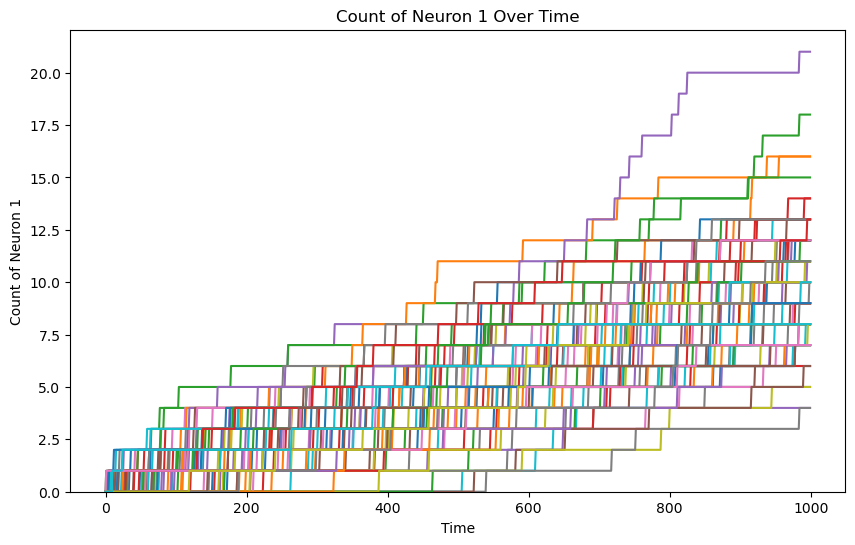

In [30]:
plot_count_neuron1_vs_time(count, num_samples)

Plots of raw counts, excitatory counts, and inhibitory counts centered and standardized.

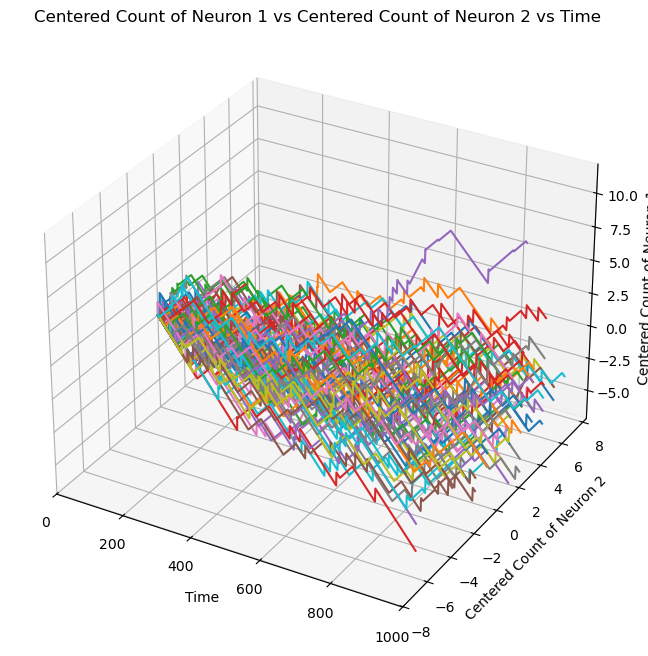

In [32]:
plot_centered_staircase_3d(count, num_samples, theoretical_means, theoretical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28620\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28620\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28620\3616601278.py:9: RuntimeWarning: divide by zero encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


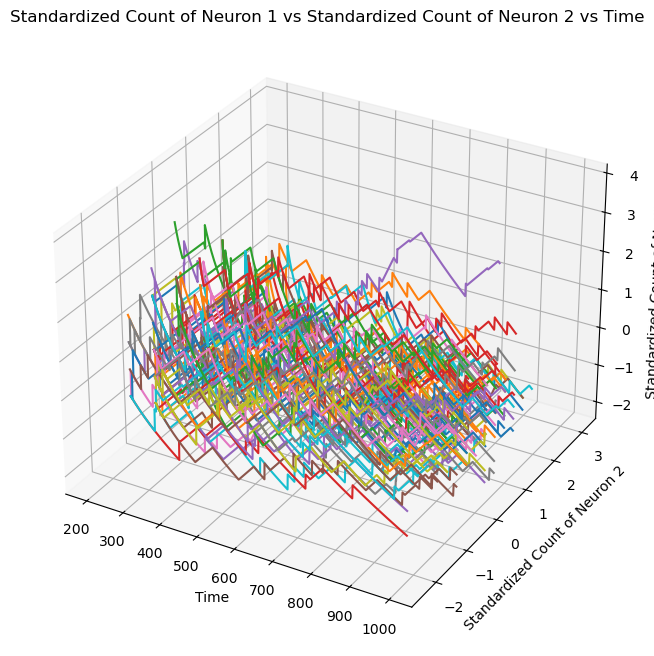

In [33]:
plot_standardized_staircase_3d(count, num_samples, theoretical_means, theoretical_std_dev, t0)

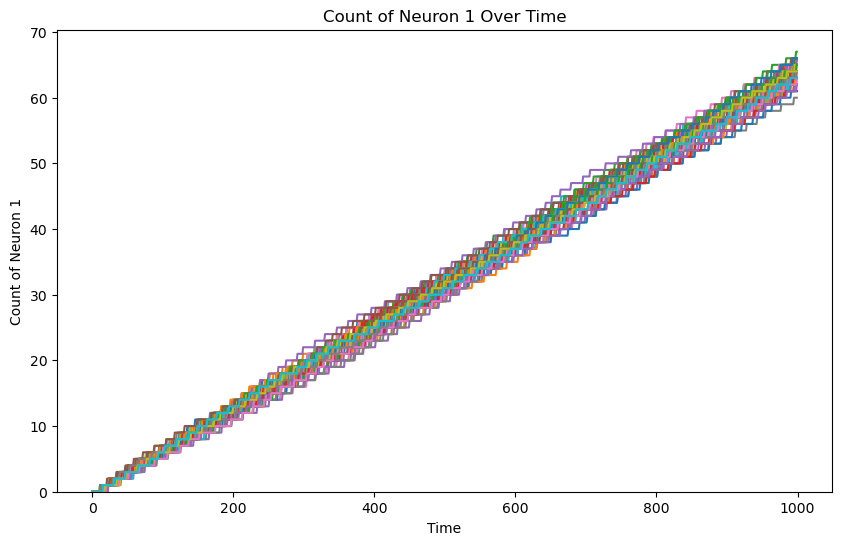

In [34]:
plot_count_neuron1_vs_time(count_ex, num_samples)

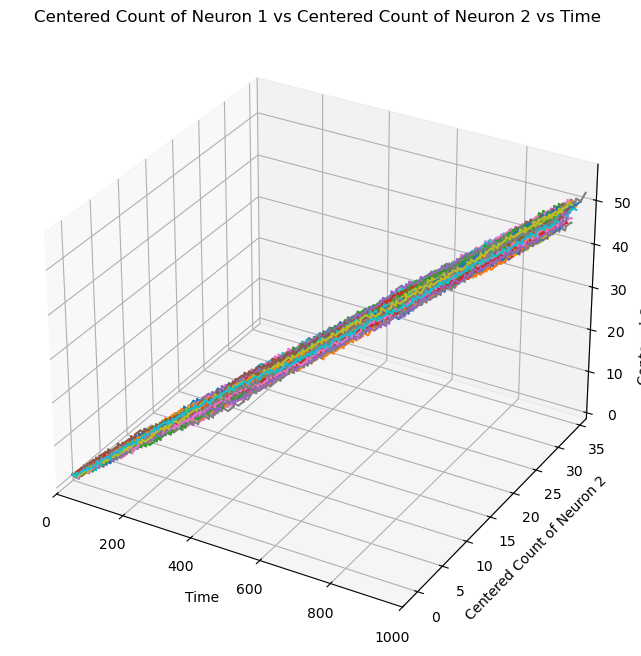

In [35]:
plot_centered_staircase_3d(count_ex, num_samples, theoretical_means, theoretical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28620\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28620\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


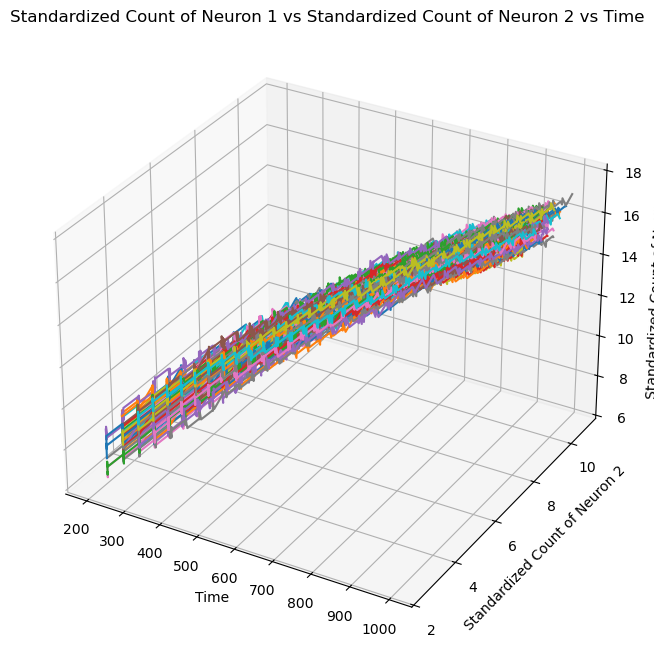

In [36]:
plot_standardized_staircase_3d(count_ex, num_samples, theoretical_means, theoretical_std_dev, t0)

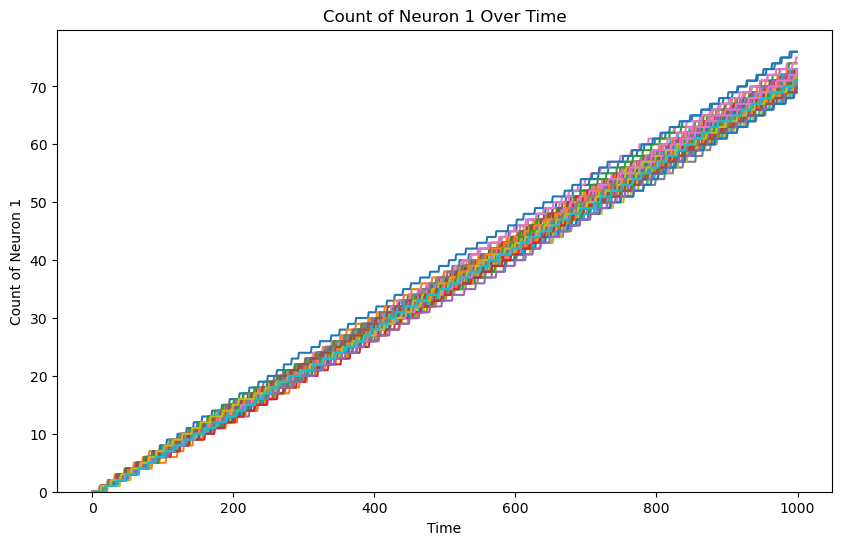

In [37]:
plot_count_neuron1_vs_time(count_in, num_samples)

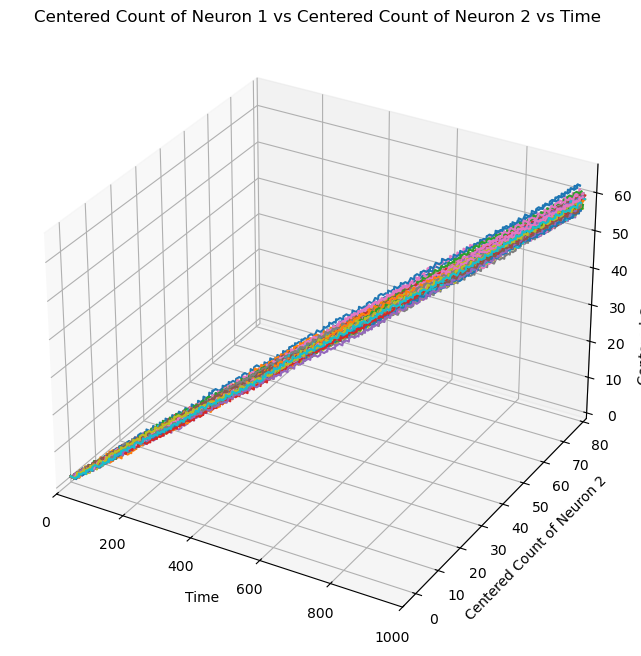

In [38]:
plot_centered_staircase_3d(count_in, num_samples, theoretical_means, theoretical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28620\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28620\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


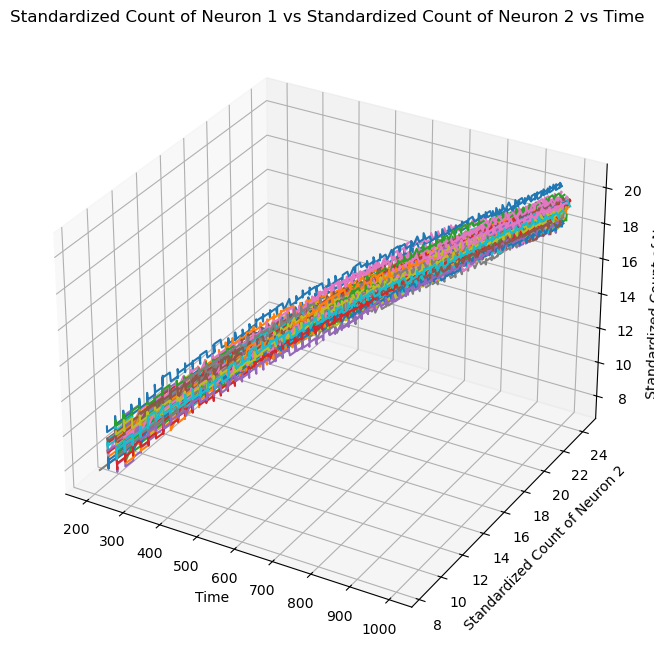

In [39]:
plot_standardized_staircase_3d(count_in, num_samples, theoretical_means, theoretical_std_dev, t0)